# Sales Data Analysis
## Data Loading

In [ ]:
import pandas as pd
df = pd.read_csv("sales_dataset.csv")

## Data Validation

In [29]:
df.head()

,CustomerId,OrderDate,SalesOrderNumber,Subtotal,TaxAmt,Freight,TotalDue,ProductID,ProductName,OrderQty,LineTotal
0,29847,2008-06-01 00:00:00.000,SO71774,880.3484,"70,4279","22,0087","972,785",836,"ML Road Frame-W - Yellow, 48",1,356.898
1,29847,2008-06-01 00:00:00.000,SO71774,880.3484,"70,4279","22,0087","972,785",822,"ML Road Frame-W - Yellow, 38",1,356.898
2,30072,2008-06-01 00:00:00.000,SO71776,78.8100,"6,3048","1,9703","87,0851",907,Rear Brakes,1,63.900
3,30113,2008-06-01 00:00:00.000,SO71780,38418.6895,"3073,4952","960,4672","42452,6519",905,"ML Mountain Frame-W - Silver, 42",4,873.816
4,30113,2008-06-01 00:00:00.000,SO71780,38418.6895,"3073,4952","960,4672","42452,6519",983,"Mountain-400-W Silver, 46",2,923.388


In [30]:
df.dtypes

CustomerId            int64
OrderDate               str
SalesOrderNumber        str
Subtotal            float64
TaxAmt                  str
Freight                 str
TotalDue                str
ProductID             int64
ProductName             str
OrderQty              int64
LineTotal           float64
dtype: object

In [31]:
df.isnull().sum()

CustomerId          0
OrderDate           0
SalesOrderNumber    0
Subtotal            0
TaxAmt              0
Freight             0
TotalDue            0
ProductID           0
ProductName         0
OrderQty            0
LineTotal           0
dtype: int64

In [32]:
df.duplicated().sum()

np.int64(0)

In [33]:
df.count()

CustomerId          542
OrderDate           542
SalesOrderNumber    542
Subtotal            542
TaxAmt              542
Freight             542
TotalDue            542
ProductID           542
ProductName         542
OrderQty            542
LineTotal           542
dtype: int64

In [34]:
df["CustomerId"].unique().size


32

In [35]:
df["ProductID"].unique().size


142

In [36]:
df["SalesOrderNumber"].unique().size

32

In [37]:
df["Subtotal"] = df["Subtotal"].str.replace(",", ".")
df["Subtotal"] = df["Subtotal"].astype(float)
print(df["Subtotal"])

AttributeError: Can only use .str accessor with string values, not floating

In [ ]:
df.dtypes

## 3 Basic Business Metrics

In [ ]:
total_rev = df["Subtotal"].sum()
print(f"Total revenue: {round((total_rev),2)}")

total_orders = int(df["SalesOrderNumber"].unique().size)
print(f"Total orders: {total_orders}")

total_customers = int(df["CustomerId"].unique().size)
print(f"Total customers: {total_customers}")

avg_order = total_rev / total_orders 
print(f"Average order value: {round((avg_order),2)}")

In [ ]:
grouped = df.groupby("CustomerId")
result = grouped["LineTotal"].sum()
result_df = pd.DataFrame(result)
result_df["NOO"] = grouped["SalesOrderNumber"].nunique()
result_df["AOV"] = result_df["LineTotal"] / result_df["NOO"]
result_df["Products_purchased"] = grouped["ProductID"].count()
result_df["Revenue_share"] = result_df["LineTotal"] / total_rev * 100.0
result_df = result_df.sort_values("LineTotal", ascending=False)
result_df["Cumulative_revenue"] = result_df["LineTotal"].cumsum() / total_rev * 100.0

result_df.head(4)

In [ ]:
grouped_clients = df.groupby("CustomerId").agg({
    "LineTotal": "sum",
    "SalesOrderNumber": "nunique",
    "ProductID":"count"
}).rename(columns = {
    "LineTotal" : "Revenue",
    "SalesOrderNumber" : "UniqueOrders",
    "ProductID" : "ProductsPurchased"

}).reset_index().sort_values("Revenue", ascending = False)

grouped_clients["Revenue_share"] = grouped_clients["Revenue"] / total_rev * 100.0
grouped_clients["Cumulative_revenue"] = grouped_clients["Revenue"].cumsum() / total_rev * 100.0

grouped_clients.head(4)

### Client revenue concentration
Clients revenue is highly concentrated.
The top 4 clients generate approximately 95% of total revenue.


In [58]:
grouped_products = df.groupby("ProductID").agg({
    "LineTotal": "sum",
    "OrderQty": "sum",
    "SalesOrderNumber": "nunique",
    "CustomerId": "nunique",
    "ProductName" : "first"
}).rename(columns = {
    "LineTotal" : "Revenue",
    "OrderQty": "UnitsSolds",
    "SalesOrderNumber": "Orders",
    "CustomerId": "Customers"
}).sort_values("Revenue", ascending = False)

grouped_products["RevenueShare"] = grouped_products["Revenue"] / total_rev * 100.0
grouped_products["Cumulative_revenue"] = grouped_products["Revenue"].cumsum() / total_rev * 100.0
top10 = grouped_products.head(10)


### Product revenue concentration
Product sales are moderately concenctrated.
The top 10 products generate approximately 83% of total revenue. 
This indicates a Pareto-like distribution where a relatively small number of products drive the majority of sales. 
However, revenue concentration is significantly stronger on the customer side, where only 4 customers generate about 95% of total revenue.
This suggests that revenue concentration is driven primarily by a few key customers rather than a small number of products.

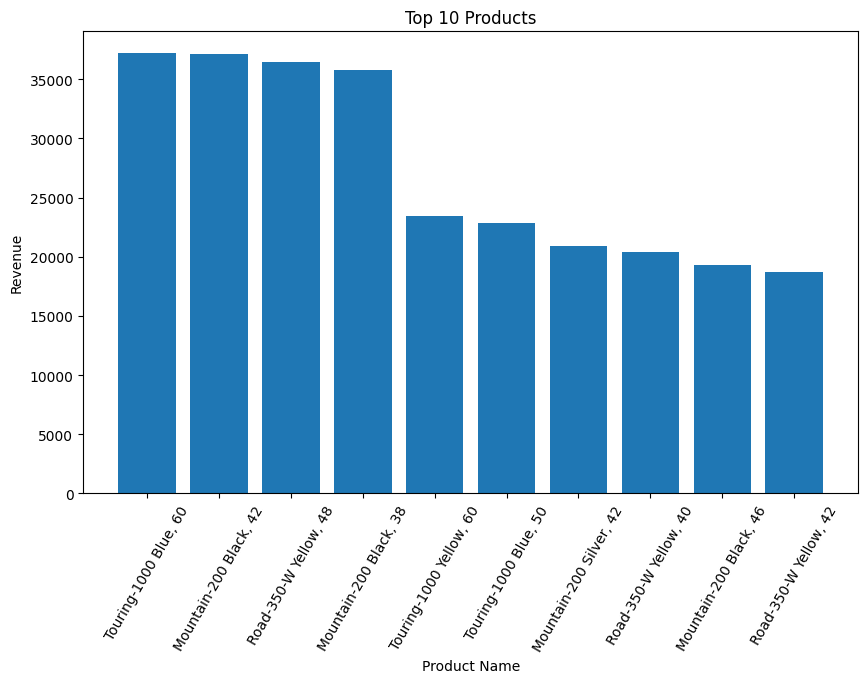

In [66]:
import matplotlib.pyplot as plt
plt.figure(figsize = (10,6))
plt.bar(top10["ProductName"], top10["Revenue"])
plt.title("Top 10 Products")
plt.xlabel("Product Name")
plt.ylabel("Revenue")
plt.xticks (rotation=60)
plt.show()